# Notebook 02 - Preprocessing & Clinical Narrative Construction

This notebook transforms raw clinical data into a structured and model-ready format. It includes rigorous data cleaning steps such as handling missing values, removing invalid or inconsistent entries, and standardising column formats.

A key contribution of this stage is the construction of textual patient narratives from structured EHR fields. Clinical attributes such as diagnoses, medications, laboratory results, and admission history are converted into coherent text representations suitable for NLP models.

The notebook also defines the target variable (30-day readmission), ensures correct label alignment, and performs dataset splitting into training, validation, and test sets using stratified sampling to preserve class distribution.

The output is a clean, consistent, and reproducible dataset pipeline ready for feature engineering and modelling.

## Environment Setup and Configuration

This section initialises the project environment by importing all required libraries and configuring system paths. Establishing a consistent environment at the beginning of the notebook is essential to ensure reproducibility and smooth execution of subsequent data processing and analysis steps.

The setup includes standard libraries for data manipulation, numerical computation, and file handling, alongside utilities for progress tracking and visualisation. In addition, project-specific configuration parameters are imported to centralise paths and experimental settings, ensuring consistency across the pipeline.

A dedicated directory is also created for storing preprocessing visualisations. This facilitates organised output management and enables easy reference to intermediate results. Finally, global plotting parameters and a consistent colour palette are defined to standardise the visual appearance of all figures generated in this notebook.

In [1]:
# Add Project Root Directory
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np
import gzip

# Regular Expressions and Warning Control
import re, warnings
warnings.filterwarnings('ignore')

# Progress Tracking Utility
from tqdm import tqdm

# Visualisation Library
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Project Configuration Paths and Parameters
from config import (
    HOSP_DIR, ICU_DIR,
    PROCESSED_DIR, LABELLED_DATASET,
    PLOTS_DIR, READMISSION_WINDOW_DAYS, 
    RANDOM_STATE, SUBSET_PATIENTS
)

# Create Preprocessing Plot Save Directory
PREPROCESSING_PLT = PLOTS_DIR / "preprocessing"
PREPROCESSING_PLT.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})


# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F']

## Data Loading and Cohort Construction

This section loads the core hospital and intensive care tables required for the study and applies an optional patient-level subset to improve memory efficiency during development. Restricting the analysis to a fixed cohort, when needed, supports reproducibility while reducing computational overhead, particularly when working with large-scale clinical data.

After identifying the patient cohort, all admission-linked tables are filtered to retain only records associated with the selected hospital admissions. This ensures consistency across data sources and avoids incorporating events that fall outside the study population. In addition to the core demographic, admission, and ICU tables, diagnosis, prescription, and outpatient measurement records are retained for subsequent feature engineering.

Laboratory events are processed separately in chunks because of their size. For each admission, the total number of laboratory measurements and the number of abnormal results are aggregated to produce a compact summary table. This provides an efficient representation of laboratory burden and abnormality patterns without requiring the full event-level table to remain in memory.

Finally, key temporal variables are converted to datetime format to support downstream derivation of time-based features. A schema validation step is also included to confirm compatibility with the expected dataset version before reporting basic loading statistics.

In [2]:
# Core Hospital Tables
patients = pd.read_csv(f'{HOSP_DIR}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_DIR}/admissions.csv.gz')
d_icd_diag = pd.read_csv(f'{HOSP_DIR}/d_icd_diagnoses.csv.gz')
d_labitems = pd.read_csv(f'{HOSP_DIR}/d_labitems.csv.gz')
icustays = pd.read_csv(f'{ICU_DIR}/icustays.csv.gz')
omr = pd.read_csv(f'{HOSP_DIR}/omr.csv.gz')

# Subset: Sample Fixed Patient Cohort For Memory Efficiency
if SUBSET_PATIENTS is not None:
    sampled_ids = (
        patients['subject_id']
        .sample(n=min(SUBSET_PATIENTS, len(patients)), random_state=42)
        .values
    )
    patients   = patients[patients['subject_id'].isin(sampled_ids)].copy()
    admissions = admissions[admissions['subject_id'].isin(sampled_ids)].copy()
    icustays   = icustays[icustays['subject_id'].isin(sampled_ids)].copy()
    omr        = omr[omr['subject_id'].isin(sampled_ids)].copy()
    print(f'Subset Applied  : {len(patients):,} patients, {len(admissions):,} admissions')
else:
    sampled_ids = patients['subject_id'].values
    print('Full Dataset    : No subset applied')

subset_hadm = set(admissions['hadm_id'].unique())

# Filtered Hospital Tables
diagnoses     = pd.read_csv(f'{HOSP_DIR}/diagnoses_icd.csv.gz')
diagnoses     = diagnoses[diagnoses['hadm_id'].isin(subset_hadm)].copy()

prescriptions = pd.read_csv(f'{HOSP_DIR}/prescriptions.csv.gz')
prescriptions = prescriptions[prescriptions['hadm_id'].isin(subset_hadm)].copy()

# Laboratory Events  
_lab_count    = {}
_abnorm_count = {}

for chunk in tqdm(
        pd.read_csv(
            f'{HOSP_DIR}/labevents.csv.gz',
            usecols=['hadm_id', 'itemid', 'flag'],
            compression='gzip',
            chunksize=500_000),
        desc='labevents chunks', unit='chunk'):

    chunk = chunk[chunk['hadm_id'].isin(subset_hadm)].dropna(subset=['hadm_id'])
    if len(chunk) == 0:
        continue
    chunk['hadm_id'] = chunk['hadm_id'].astype(int)
    chunk['is_abnormal'] = (
        chunk['flag'].fillna('').str.strip().str.lower()
        .isin(['abnormal', 'delta'])
    ).astype(int)
    grp = chunk.groupby('hadm_id').agg(
        n=('itemid', 'count'), n_abn=('is_abnormal', 'sum'))
    for hadm_id, row in grp.iterrows():
        _lab_count[hadm_id]    = _lab_count.get(hadm_id, 0)    + int(row['n'])
        _abnorm_count[hadm_id] = _abnorm_count.get(hadm_id, 0) + int(row['n_abn'])

lab_summary = pd.DataFrame({
    'hadm_id'       : list(_lab_count.keys()),
    'lab_count'     : list(_lab_count.values()),
    'abnormal_count': [_abnorm_count.get(h, 0) for h in _lab_count],
})
lab_summary['pct_abnormal'] = (
    lab_summary['abnormal_count'] / lab_summary['lab_count'] * 100
).round(1)
del _lab_count, _abnorm_count
print(f'Lab Summary Computed For {len(lab_summary):,} Admissions')

# Convert Temporal Columns To Datetime Format
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')
prescriptions['starttime'] = pd.to_datetime(prescriptions['starttime'], errors='coerce')


# Validate Dataset Schema Version 
assert 'loinc_code' not in d_labitems.columns, \
    'Unexpected loinc_code column -- check dataset version'


# Display Dataset Summary Statistics
print('All tables loaded.')
print(f'Admissions : {len(admissions):,}')
print(f'Patients : {len(patients):,}')
print(f'OMR records : {len(omr):,}')

Subset Applied  : 25,000 patients, 36,889 admissions


labevents chunks: 317chunk [07:38,  1.45s/chunk]


Lab Summary Computed For 30,312 Admissions
All tables loaded.
Admissions : 36,889
Patients : 25,000
OMR records : 521,072


## Readmission Label Construction and Cohort Filtering

This section constructs the primary outcome variable for the study, namely 30-day hospital readmission. Accurate label definition is critical in clinical prediction tasks, as improper handling of mortality or temporal relationships can introduce bias and misrepresent patient outcomes.

Admissions are first ordered chronologically within each patient to enable identification of subsequent hospitalisations. This allows the calculation of the time interval between discharge and the next admission, which forms the basis for defining readmission events. In parallel, mortality information is incorporated to distinguish between patients who are eligible for readmission and those who are not.

Two forms of mortality are considered: in-hospital death and post-discharge death within 30 days. Admissions resulting in death are excluded or corrected to ensure that patients who could not possibly be readmitted are not incorrectly labelled as negative cases. This adjustment is essential to avoid artificially inflating model performance.

The final readmission label is defined based on whether a subsequent admission occurs within the specified time window, subject to mortality constraints. The resulting cohort is then restricted to patients who survived their hospital stay, and the class distribution is examined to assess imbalance. A visualisation of the label distribution is also generated to support interpretation and guide downstream modelling decisions.

Label distribution (excluding in-hospital deaths):
  Not readmitted (0):  29,157  (80.8%)
  Readmitted (1):   6,939  (19.2%)

Excluded (died in hospital)  : 793
Label-corrected (died <30d)  : 890


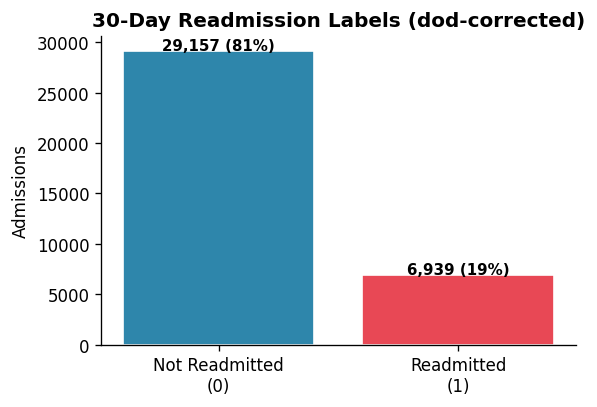

In [3]:
# Sort Admissions Chronologically Within Each Patient
adm = admissions.sort_values(['subject_id', 'admittime']).copy()


# Merge Date Of Death Information
adm = adm.merge(
    patients[['subject_id', 'dod']],
    on='subject_id',
    how='left'
)


# Flag In-Hospital Mortality
if 'hospital_expire_flag' in adm.columns:
    adm['died_in_hospital'] = (
        adm['hospital_expire_flag']
        .fillna(0)
        .astype(int)
    )
else:
    adm['died_in_hospital'] = 0


# Flag Post-Discharge Death Within 30 Days Using Date Of Death
adm['died_within_30d'] = (
    adm['dod'].notna() &
    (
        (adm['dod'] - adm['dischtime'])
        .dt.total_seconds() / 86400
    ).between(0, 30)
).astype(int)


# Calculate Length Of Stay In Days
adm['los_days'] = (
    (adm['dischtime'] - adm['admittime'])
    .dt.total_seconds() / 86400
)


# Identify Next Admission Timing Per Patient
adm['next_admittime'] = (
    adm.groupby('subject_id')['admittime']
    .shift(-1)
)

adm['days_to_next'] = (
    (adm['next_admittime'] - adm['dischtime'])
    .dt.total_seconds() / 86400
)


# Construct 30-Day Readmission Label With Mortality Correction
adm['readmission_30d'] = (
    adm['days_to_next'].between(0, READMISSION_WINDOW_DAYS) &
    (adm['died_in_hospital'] == 0) &
    (adm['died_within_30d'] == 0)
).astype(int).fillna(0).astype(int)


# Exclude Admissions With In-Hospital Mortality
adm_alive = (
    adm[adm['died_in_hospital'] == 0]
    .copy()
)


# Display Label Distribution
vc = adm_alive['readmission_30d'].value_counts()

print('Label distribution (excluding in-hospital deaths):')

for k, v in vc.items():
    lbl = 'Readmitted (1)' if k == 1 else 'Not readmitted (0)'
    print(
        f'  {lbl}: {v:>7,}  '
        f'({v / len(adm_alive) * 100:.1f}%)'
    )


# Display Mortality Exclusion Statistics
in_hosp_excl = adm['died_in_hospital'].sum()
dod30_excl   = adm['died_within_30d'].sum()

print(f'\nExcluded (died in hospital)  : {in_hosp_excl:,}')
print(f'Label-corrected (died <30d)  : {dod30_excl:,}')


# Visualise Readmission Label Distribution
fig = plt.figure(figsize=(5, 3.5))

gs = gridspec.GridSpec(
    1,
    1,
    figure=fig
)

ax1 = fig.add_subplot(gs[0])

bars = ax1.bar(
    ['Not Readmitted\n(0)', 'Readmitted\n(1)'],
    [vc.get(0, 0), vc.get(1, 0)],
    color=[PALETTE[0], PALETTE[1]],
    edgecolor='white'
)

for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{val:,} ({val / len(adm_alive) * 100:.0f}%)',
        ha='center',
        fontweight='bold',
        fontsize=9
    )


ax1.set_title(
    '30-Day Readmission Labels (dod-corrected)',
    fontweight='bold'
)

ax1.set_ylabel('Admissions')


# Figure Formatting And Export
plt.tight_layout()

plt.savefig(
    f'{PREPROCESSING_PLT}/pre_01_label_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Diagnosis Code Mapping and Text Normalisation

This section enriches diagnosis records by mapping ICD codes to their corresponding descriptive titles. Converting coded clinical information into human-readable text is an important step for improving interpretability and enabling downstream text-based feature engineering.

Where descriptive titles are unavailable, the original ICD codes are retained to preserve information completeness. This ensures that no diagnosis entries are discarded due to missing metadata, maintaining consistency across the dataset.

To prepare diagnosis titles for analysis, a standardised text cleaning procedure is applied. This involves lowercasing, removal of non-alphanumeric characters, and basic normalisation to reduce variability in textual representations. Such preprocessing is essential for constructing a consistent vocabulary and improving the effectiveness of feature extraction techniques.

Finally, the size of the resulting diagnosis vocabulary is reported, providing an indication of the diversity of clinical conditions represented within the study cohort.

In [4]:
# Merge Diagnosis Codes With Descriptive Titles
dx = diagnoses.merge(
    d_icd_diag[['icd_code', 'icd_version', 'long_title']],
    on=['icd_code', 'icd_version'],
    how='left'
)


# Replace Missing Titles With Original ICD Codes
dx['long_title'] = dx['long_title'].fillna(dx['icd_code'])


# Define Text Cleaning Function For Diagnosis Titles
def _clean(t):
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9 ,./()-]', '', t)
    return t.strip()


# Generate Normalised Diagnosis Titles
dx['clean_title'] = dx['long_title'].apply(_clean)


# Display Diagnosis Vocabulary Size
print(
    f'Diagnosis vocabulary: '
    f'{dx["clean_title"].nunique():,} unique titles'
)

Diagnosis vocabulary: 12,913 unique titles


## Medication Name Standardisation and Frequency Analysis

This section standardises medication names to create a consistent representation suitable for analysis. Raw prescription data often contains variations in formatting, including differences in casing, spacing, and the presence of special characters. Without normalisation, such inconsistencies can artificially inflate the number of unique medications and reduce the reliability of frequency-based features.

To address this, medication names are converted to lowercase, stripped of extraneous whitespace, and cleaned to retain only alphanumeric characters. This preprocessing step ensures that semantically identical drug names are treated uniformly, thereby improving the quality of downstream aggregation and modelling.

Following standardisation, the most frequently prescribed medications are identified. Examining the top medications provides insight into common treatment patterns within the cohort and helps validate that the preprocessing step has produced meaningful and interpretable results.

In [5]:
# Standardise Medication Names
prescriptions['drug_clean'] = (
    prescriptions['drug']
    .str.lower()
    .str.strip()
    .apply(
        lambda x: re.sub(
            r'[^a-z0-9 ]',
            '',
            str(x)
        ).strip()
    )
)


# Display Most Frequent Medications
print('Top 10 medications:')

print(
    prescriptions['drug_clean']
    .value_counts()
    .head(10)
    .to_string()
)

Top 10 medications:
drug_clean
insulin                      54667
09 sodium chloride           48405
sodium chloride 09  flush    45709
potassium chloride           45589
acetaminophen                40188
furosemide                   30130
heparin                      27322
magnesium sulfate            25057
5 dextrose                   24088
hydromorphone dilaudid       23807


## Laboratory Summary Overview

This section provides a preliminary overview of the aggregated laboratory features constructed in the previous step. The laboratory summary table captures, for each admission, the total number of laboratory measurements and the proportion of abnormal results.

Inspecting the size and structure of this table is important to verify that the aggregation process has been performed correctly and that all relevant admissions are represented. It also offers an initial understanding of the distribution of laboratory activity across the cohort.

A sample of the table is displayed to confirm the presence of key variables and to ensure consistency in the computed features before proceeding to further analysis and feature engineering.

In [6]:
# Lab Summary 
print(f'Lab Summary : {len(lab_summary):,} admissions')
print(lab_summary.head())

Lab Summary : 30,312 admissions
    hadm_id  lab_count  abnormal_count  pct_abnormal
0  20070925         44              13          29.5
1  20075017         79              15          19.0
2  20083129        164             101          61.6
3  20198088        186              35          18.8
4  20199878         56              16          28.6


## OMR Data Processing and Recent Measurement Extraction

This section processes outpatient measurement records (OMR) to extract clinically relevant features for each patient. These records contain time-stamped physiological measurements such as body mass index (BMI) and weight, which can provide important context for patient health status.

The timestamp column is first converted to a standard datetime format to enable chronological ordering of observations. Measurement values are also coerced into numeric format to ensure compatibility with quantitative analysis and to handle potential inconsistencies in the raw data.

A utility function is then defined to retrieve the most recent measurement for a given variable of interest. For each patient, records matching a specified measurement pattern are filtered, cleaned, and sorted temporally, after which only the latest available value is retained. This approach ensures that each patient is represented by their most up-to-date clinical measurement.

Finally, recent BMI and weight values are extracted, and their availability across the cohort is reported. This provides insight into data coverage and highlights potential sparsity in outpatient measurement records.

In [7]:
# Convert OMR Timestamp Column To Datetime
omr['chartdate'] = pd.to_datetime(
    omr.get('chartdate', omr.get('result_time', None)),
    errors='coerce'
)

# Convert Measurement Values To Numeric Format
omr['result_value_num'] = pd.to_numeric(
    omr['result_value'],
    errors='coerce'
)


# Define Function To Extract Most Recent Measurement Per Patient
def latest_omr(result_name_pattern):
    sub = omr[
        omr['result_name']
        .str.lower()
        .str.contains(result_name_pattern, na=False)
    ].copy()

    sub = sub.dropna(subset=['result_value_num'])

    sub = (
        sub.sort_values('chartdate')
        .groupby('subject_id')
        .last()[['result_value_num']]
    )

    return sub.rename(
        columns={'result_value_num': result_name_pattern}
    )


# Extract Recent BMI And Weight Measurements
omr_bmi    = latest_omr('bmi')
omr_weight = latest_omr('weight')


# Display Measurement Availability Statistics
print(f'Patients with recent BMI : {len(omr_bmi):,}')
print(f'Patients with recent weight : {len(omr_weight):,}')

Patients with recent BMI : 10,954
Patients with recent weight : 11,812


## Lookup Table Construction and Demographic Feature Derivation

This section constructs a series of lookup tables to enable efficient retrieval of patient- and admission-level information during feature engineering. Precomputing these mappings significantly reduces computational overhead by avoiding repeated group-by operations in later stages of the pipeline.

Diagnosis, medication, ICU stay duration, and laboratory summaries are aggregated at the admission level and stored as dictionaries keyed by hospital admission identifiers. This structure allows rapid access to all relevant clinical information associated with a given admission. Similarly, physiological measurements such as BMI and weight are mapped at the patient level to support integration with admission-level data.

In addition to lookup construction, a utility function is defined to estimate patient age at the time of admission. Since age information is provided in an anonymised format using anchor year and anchor age, the function adjusts these values to approximate the patient’s age at each admission. Special handling is included for patients with truncated age values to preserve consistency with dataset conventions.

Together, these components establish an efficient and scalable foundation for assembling feature-rich datasets in subsequent steps.

In [8]:
# Create Patient-Level Index For Fast Lookup
pt_idx = patients.set_index('subject_id')

# Build Diagnosis Lookup By Admission
dx_by_hadm = (
    dx.groupby('hadm_id')['clean_title']
    .apply(list)
    .to_dict()
)

# Build Medication Lookup By Admission
rx_by_hadm = (
    prescriptions
    .groupby('hadm_id')['drug_clean']
    .apply(lambda s: list(s.dropna().unique()))
    .to_dict()
)

# Build ICU Length Of Stay Lookup By Admission
icu_by_hadm = (
    icustays
    .groupby('hadm_id')['los']
    .sum()
    .to_dict()
)

# Build Laboratory Summary Lookup By Admission
lab_by_hadm = (
    lab_summary
    .set_index('hadm_id')
    .to_dict('index')
)


# Build Physiological Measurement Lookup By Patient
bmi_by_pt = omr_bmi['bmi'].to_dict()
wt_by_pt  = omr_weight['weight'].to_dict()


# Define Function To Estimate Age At Admission
def get_age(subject_id, admit_year):
    row = pt_idx.loc[subject_id]

    raw_age = max(
        0,
        int(row['anchor_age'])
        + (admit_year - int(row['anchor_year']))
    )
    
    if int(row['anchor_age']) == 91:
        return '91+'
    return str(raw_age)

## Structured Clinical Narrative Construction

This section defines a function to construct structured clinical narratives for each hospital admission. Transforming heterogeneous clinical data into a unified textual representation enables the integration of demographic, diagnostic, treatment, and physiological information in a format suitable for downstream modelling, particularly for natural language processing approaches.

The narrative incorporates multiple data sources, including patient demographics, admission history, diagnoses, medications, laboratory summaries, ICU utilisation, and outpatient measurements. Each component is selectively included and summarised to ensure that the resulting text remains informative while avoiding excessive verbosity. Where data is unavailable, default placeholders are used to maintain consistency across records.

Temporal context is also incorporated by including information from prior admissions, when available. This provides additional clinical background and allows the model to capture longitudinal patterns in patient history, which may be predictive of readmission risk.

Overall, this structured narrative serves as a compact yet comprehensive representation of each admission, enabling the application of text-based learning methods while preserving key clinical signals from multiple modalities.

In [9]:
# Function To Build Structured Clinical Narrative
def build_narrative(subject_id, hadm_id, admit_idx, admit_row, all_patient_adm):
    # Retrieve Patient Demographic Information
    row = pt_idx.loc[subject_id]
    gender = 'male' if row['gender'] == 'M' else 'female'

    age = get_age(
        subject_id,
        admit_row['admittime'].year
    )

    n_prior = admit_idx


    # Extract Current Admission Diagnoses
    curr_diag = dx_by_hadm.get(hadm_id, [])

    diag_str = (
        ', '.join(curr_diag[:8])
        if curr_diag
        else 'no diagnoses recorded'
    )


    # Extract Current Admission Medications
    curr_meds = rx_by_hadm.get(hadm_id, [])

    meds_str = (
        ', '.join(curr_meds[:8])
        if curr_meds
        else 'no medications recorded'
    )


    # Extract ICU Length Of Stay Information
    icu_los = icu_by_hadm.get(hadm_id, 0)

    icu_str = (
        f'admitted to ICU for {icu_los:.1f} days'
        if icu_los > 0
        else 'no ICU stay'
    )


    # Extract Laboratory Summary Information
    lab_info = lab_by_hadm.get(hadm_id, {})

    lab_str = (
        f'{lab_info["lab_count"]} lab tests, '
        f'{lab_info["pct_abnormal"]:.0f}% abnormal'
        if lab_info
        else 'no laboratory data'
    )


    # Extract OMR Physiological Measurements
    bmi_val = bmi_by_pt.get(subject_id)
    wt_val  = wt_by_pt.get(subject_id)

    vitals_parts = []

    if bmi_val and 10 < bmi_val < 80:
        vitals_parts.append(f'BMI {bmi_val:.1f}')

    if wt_val and 20 < wt_val < 300:
        vitals_parts.append(f'weight {wt_val:.0f}')

    vitals_str = (
        ', '.join(vitals_parts)
        if vitals_parts
        else 'vitals not recorded'
    )


    # Add Prior Admission Context If Available
    prior_context = ''

    if n_prior > 0:
        prev_hadm = int(
            all_patient_adm.iloc[admit_idx - 1]['hadm_id']
        )

        prev_diag = dx_by_hadm.get(prev_hadm, [])

        if prev_diag:
            prior_context = (
                f' Prior admission diagnoses included: '
                f'{", ".join(prev_diag[:4])}.'
            )


    # Construct Final Narrative String
    return (
        f"Patient is a {age}-year-old {gender}. "
        f"This is admission {admit_idx + 1} "
        f"({n_prior} prior admission(s)).{prior_context} "
        f"Current diagnoses: {diag_str}. "
        f"Current medications: {meds_str}. "
        f"Laboratory summary: {lab_str}. "
        f"Vitals (OMR): {vitals_str}. "
        f"ICU status: {icu_str}."
    )

## Narrative Dataset Construction

This section constructs the final modelling dataset by generating structured clinical narratives for each admission. Building on the previously defined narrative function, this step iterates through all patients and their chronologically ordered admissions to produce a comprehensive, text-based representation of each hospital encounter.

Admissions are first sorted within each patient to preserve temporal ordering, ensuring that prior admission context is accurately incorporated into each narrative. The dataset is then constructed by iterating over each patient group and generating narratives sequentially for all admissions. Alongside the narrative text, additional metadata such as admission timing, admission sequence, prior admission count, and length of stay are recorded.

Basic quality control is implemented during generation, with failed cases tracked and excluded to maintain dataset integrity. The resulting records are aggregated into a structured DataFrame, forming the primary dataset for downstream modelling tasks.

Finally, summary statistics are reported, including the total number of records, the number of skipped entries, and the distribution of the target variable. This provides an initial validation of dataset completeness and highlights any class imbalance that may need to be addressed in subsequent modelling stages.

In [10]:
# Sort Admissions For Narrative Generation
adm_for_narratives = (
    adm_alive
    .sort_values(['subject_id', 'admittime'])
)

# Initialise Storage Containers
records = []
skipped = 0


# Iterate Through Patients And Generate Narratives
for subject_id, group in tqdm(
        adm_for_narratives.groupby('subject_id'),
        desc='Building narratives',
        unit='patient'):

    pt_adm = group.reset_index(drop=True)

    for pos in range(len(pt_adm)):
        row     = pt_adm.iloc[pos]
        hadm_id = row['hadm_id']

        try:
            narrative = build_narrative(
                subject_id,
                int(hadm_id),
                pos,
                row,
                pt_adm
            )

            records.append({
                'subject_id' : subject_id,
                'hadm_id' : hadm_id,
                'admittime' : row['admittime'],
                'dischtime' : row['dischtime'],
                'admit_number' : pos + 1,
                'n_prior_admissions' : pos,
                'narrative' : narrative,
                'word_count' : len(narrative.split()),
                'readmission_30d' : int(row['readmission_30d']),
                'los_days' : round(float(row['los_days']), 2)
            })

        except Exception:
            skipped += 1


# Convert Records To DataFrame
dataset = pd.DataFrame(records)

# Display Dataset Summary Statistics
print(f'\nTotal records  : {len(dataset):,}')
print(f'Skipped        : {skipped}')

print(
    f'\nLabel dist:\n'
    f'{dataset["readmission_30d"].value_counts().to_string()}'
)

Building narratives: 100%|██████████| 15003/15003 [00:13<00:00, 1114.92patient/s]



Total records  : 36,096
Skipped        : 0

Label dist:
readmission_30d
0    29157
1     6939


## Final Dataset Export and Summary Statistics

This section finalises the dataset by saving the structured clinical narratives and associated features to disk. Persisting the dataset ensures that the preprocessing pipeline does not need to be recomputed in subsequent experiments, thereby improving efficiency and reproducibility.

In addition to exporting the dataset, key summary statistics are reported to provide an overview of its composition. These include the total number of samples, class distribution of the readmission label, number of unique patients, and descriptive statistics of narrative length. Such metrics are important for validating dataset integrity and identifying potential issues such as class imbalance or excessively short or long narratives.

Additional confirmations are included to indicate the incorporation of physiological measurements and the application of mortality corrections. Together, these summaries provide a concise validation of the dataset prior to downstream modelling and evaluation.

In [11]:
# Save Final Labelled Dataset To Disk
dataset.to_csv(
      LABELLED_DATASET,
      index=False
)

print('=' * 64)

# Display Dataset Summary Statistics
print(
      f'  Total samples               : '
      f'{len(dataset):,}'
)

print(
      f'  Positive (readmitted)       : '
      f'{dataset["readmission_30d"].sum():,} '
      f'({dataset["readmission_30d"].mean() * 100:.1f}%)'
)

print(
      f'  Unique patients             : '
      f'{dataset["subject_id"].nunique():,}'
)

print(
            f'  Avg words / narrative       : '
            f'{dataset["word_count"].mean():.1f} '
            f'+/- {dataset["word_count"].std():.1f}'
)

print(
      f'  Dataset includes OMR vitals : '
      f'YES (BMI/weight from omr table)'
)

print(
      f'  dod mortality correction    : '
      f'YES (in-hosp deaths excluded)'
)

print('=' * 64)

  Total samples               : 36,096
  Positive (readmitted)       : 6,939 (19.2%)
  Unique patients             : 15,003
  Avg words / narrative       : 96.9 +/- 26.1
  Dataset includes OMR vitals : YES (BMI/weight from omr table)
  dod mortality correction    : YES (in-hosp deaths excluded)
